### Imports

In [1]:
import pandas as pd
from ImpararePackage import dataRequest

from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn import tree

import joblib

import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

## Download da tabela 'imparare2_dataset_label_full'

In [2]:
query = """
    select 
        pa."caso infeccao",
        pa."caso infeccao hospitalar",
        pa."Conjuntivite",
        pa."Infecção da cavidade oral",
        pa."Infecção de pele",
        pa."Meningite",
        pa.comunitaria,
        pa.enterocolite,
        pa.ipcs,
        pa.isc,
        pa.pav as infeccao_pav,
        dtp.*
    from imparare2_train_wellhead_set_prepared dtp
    inner join new_avaliacao_padrao_ouro pa
        on dtp."REGISTRO" = pa.registro 
            and dtp."DIA_parsed" = pa.dt_infeccao
"""

df = dataRequest.get_data(queryText= query, chunck= None)

In [3]:
import pandas as pd

# lista de colunas
cols = pd.Series(df.columns)

# pega só as duplicadas
duplicadas = cols[cols.duplicated()]

print(duplicadas)

Series([], dtype: str)


In [4]:
df.to_feather("dataset_dia_6_abril.feather")

### Organização de Variáveis

In [5]:
# Dado controle - quem é e de quando é
dados_controle = ["REGISTRO", "DIA_parsed", "dthr_internacao", "dthr_alta"]

# Dado texto: 
dado_categoricos = ["UNIDADE_INTERNACAO", "ESPECIALIDADE_INTERNACAO", "TIPO_INTERNACAO", "CLINICA_INTERNACAO", "SEXO", "TEMP_INCUBADORA_min", "TEMP_INCUBADORA_max", "TEMP_INCUBADORA_count", "TEMP_INCUBADORA_avg", "TEMP_INCUBADORA_stddev", "TEMP_INCUBADORA_delta", "UNIDADE_fim_janela", "UNIDADE_inicio_janela", "agg_hemocultura", "agg_urocultura"]

# Gabaritos
gabaritos = ['caso infeccao', 'caso infeccao hospitalar', 'Conjuntivite', 'Infecção da cavidade oral', 'Infecção de pele', 'Meningite', 'comunitaria', 'enterocolite', 'ipcs', 'isc', 'pav']

# Features
features_atendimento = ["IDADE", "los_dias", "los_horas"]

features_cirurgias = ["CIRURGIA_tempo_total", "CIRURGIA_procedimentos_total"]

# Sinais vitais
features_sinal_vital = ["TECNICO(A) EM ENFERMAGEM_count", "TECNICO(A) EM ENFERMAGEM_avg", "ENFERMEIRO(A)_count", "ENFERMEIRO(A)_avg", "AUXILIAR DE ENFERMAGEM_count", "AUXILIAR DE ENFERMAGEM_avg", "ACADEMICODE ENFERMAGEM_count", "ACADEMICO DE ENFERMAGEM_avg", "MEDICO_count", "MEDICO_avg", "FISIOTERAPEUTA_count", "FISIOTERAPEUTA_avg", "OUTROS_count", "OUTROS_avg", "DIUR_min", "DIUR_max", "DIUR_count", "DIUR_avg", "DIUR_stddev", "DIUR_delta", "FC_min", "FC_max", "FC_count", "FC_avg", "FC_stddev", "FC_delta", "FR_min", "FR_max", "FR_count", "FR_avg", "FR_stddev", "FR_delta", "HGT_min", "HGT_max", "HGT_count", "HGT_avg", "HGT_stddev", "HGT_delta", "OXIMETRIA_min", "OXIMETRIA_max", "OXIMETRIA_count", "OXIMETRIA_avg", "OXIMETRIA_stddev", "OXIMETRIA_delta", "PAD_min", "PAD_max", "PAD_count", "PAD_avg", "PAD_stddev", "PAD_delta", "PAS_min", "PAS_max", "PAS_count", "PAS_avg", "PAS_stddev", "PAS_delta", "TEMP_min", "TEMP_max", "TEMP_count", "TEMP_avg", "TEMP_stddev", "TEMP_delta", "PA_min", "PA_max", "PA_count", "PA_avg", "PA_stddev", "PA_delta", "PAM_min", "PAM_max", "PAM_count", "PAM_avg", "PAM_stddev", "PAM_delta", "O2_min", "O2_max", "O2_count", "O2_avg", "O2_stddev", "O2_delta", "FIO2_min", "FIO2_max", "FIO2_count", "FIO2_avg", "FIO2_stddev", "FIO2_delta", "PEEP_min", "PEEP_max", "PEEP_count", "PEEP_avg", "PEEP_stddev", "PEEP_delta", "SINAIS_VITAIS_registros_total", "FEBRE_indicada"]

# Volumetrico evos e movimentacao
features_evol = ["UNIDADE_movimento_total", "EVOLUCAO_notas_total", "EVOLUCAO_notas_total_dia"]

# Antibioticos utilizados
features_atb = ["aciclovir_count", "amoxicilina_sulbactam_count", "cefadroxila_count", "cefalotina_count", "cefotaxima_count", "ceftazidima_count", "ceftazidima_avibactam_count", "ceftalozana_tazobactam_count", "cetoconazol_count", "claritromicina_count", "cloranfenicol_count", "doxiciclina_count", "ertapenem_count", "eritromicina_count", "ganciclovir_count", "ivermectina_count", "micafungina_count", "miconazol_count", "moxifloxacino_count", "mupirocina_count", "neomicina_count", "rifampicina_count", "sulfadiazina_count", "teicoplanina_count", "voriconazol_count", "ciprofloxacino_count", "outro_count", "amicacina_count", "amoxicilina_clavulanato_count", "amoxicilina_count", "ampicilina_count", "azitromicina_count", "penicilinagbenzatina_count", "penicilinagpotassica_count", "cefalexina_count", "cefazolina_count", "cefepima_count", "ceftriaxona_count", "cefuroxima_count", "clindamicina_count", "fluconazol_count", "gentamicina_count", "levofloxacino_count", "linezolida_count", "meropenem_count", "metronidazol_count", "nistatina_count", "oxacilina_count", "piperacilina_tazobactam_count", "ampicilina_sulbactam_count", "sulfametoxazol_trimetoprim_count", "polimixinab_count", "tobramicina_count", "vancomicina_count", "via_topico_count", "via_sng_count", "via_outro_count", "via_ev_count", "via_im_count", "via_vo_count"]

# Dados de exame
# Culturais
features_culturais = ["qtd_hemocultura_positiva", "qtd_hemocultura_sem_crescimento", "qtd_cultura_positiva", "qtd_cultura_sem_crescimento", "qtd_bacteroscopico_positiva", "qtd_bacteroscopico_negativa", "qtd_urocultura_positiva", "qtd_urocultura_sem_crescimento", "qtd_bacteriologico_positiva", "qtd_bacteriologico_sem_crescimento"]

# Sangue
features_sangue = ["leuco_min", "leuco_max", "leuco_avg", "rdw_min", "rdw_max", "rdw_avg", "neuto_min", "neuto_max", "neuto_avg"]

# Laudos Imagem
features_laudos_imagem = ["RAGIOLOGIA_laudos_total"]

# Proporção de termos no texto 
features_proporcao_texto = ["tosse", "ronco", "cavita", "opac", "infil", "fibrose_cistica", "sec_pur_pulmonar", "secr", "puru", "secr_traq", "o2", "dpoc", "hemoptise", "leucemia", "esplenectomia", "febre", "consol", "linfoma", "acinetobacter", "amarelada", "aspiracao", "broncograma_aereo", "crepitante", "enterobacter", "enterococcus", "hemophylus", "hipertermia", "imunossuprimido", "infeccao", "klebsiella", "legionella", "leucocitose", "leucopenia", "moraxella", "pneumococcus", "pseudomonas", "sibilos", "intubacao", "staphylococcus_aureus", "sepse_pulmonar", "sepse_respiratoria", "sepse_urinaria", "padrao_ventilatorio", "insuficiencia_ventilatoria", "esforco_ventilatorio", "lavado_broncoalveolar", "derrame_pleural", "escherichia_coli", "choque_septico", "dor_pleuritica", "dor_ventilatorio_dependente", "ventilacao_mecanica", "iot", 
                            # "pav_1",
                            "endoftalmite", "eritema", "hiperemia", "mediastinite", "staphylococcus_coagulase_negativo", "supuracao", "rubor", "mal_estar", "abscesso", "calor", "dreno", "edema", "endocardite", "antibiotico", "bacteriologico", "deiscencia", "resistente", "taquicardia", "cateter", "cateter_arterial", "cateter_urinario", "cvc", "cateter_venoso_periferico", "clorose", "instabilidade", "oliguria", "hipotensao", "anuria", "bacteremia", "bacteriuria", "disuria", "leucocituria", "nitrito", "svd", "tsa", "choque", "staphylococcus", "e_coli", "colecao", "tremor", "calafrio", "pos_operatorio", "dor_suprapubica", "foco_urinario", "colite_pseudomembranosa", "yersinia", "vomito", "shigella", "salmonela", "nausea", "giardia", "dor_cabeca", "dor_abdominal", "diarreia", "clostridium", "campylobacter", "urgencia_urinaria", "urgencia_miccional", "sondagem_alivio", "sondagem_vesical", "urocultura", "piuria", "albumina", "press_parc_co2", "bicarbonato", "calcio", "creatinina", "glicose", "hemoglobina", "plaquetas", "potassio", "sodio", "bilirrubina", "cardiomegalia", "lesao_pulmonar", "pneumonia", "atelectasia", "pneumotorax", "fratura", "freq_respiratoria", "freq_cardiaca", "pressao_sanguinea", "saturacao_sangue", "hemocultura", "temperatura", "ph_sangue", "propionibacterium", "cryptococcus", "pneumocystis", "histoplasma", "paracoccidioides", "bacteroides", "candida", "fusobacterium", "peptostreptococcus", "sibilancia", "hipotermia", "apneia", "bradicardia", "streptococcus_viridans", "consciencia", "hcm", "hgm", "corynebacterium", "bacillus", "aerococcus", "coccidioides", "veillonella", "covid", "peep", "fio2", "spo2", "avc", "sne", "desnutricao", "sedacao", "vsg", "fosfatase_alcalina", "ldh", "cetamina", "propofol", "clorpromazina", "fentanil", "pancuronio", "noradrenalina", "diazepan", "lorazepan", "flumazenil", "clonidina", "npt", "cateter_monolumen", "cateter_duplolumen", "cateter_triplolumen", "portocath", "cateter_hickmann", "shilley", "obesidade", "diabetes", "neutropenia", "tabagismo"]

# contagem de termos em texto
features_contagem_texto = ["tosse_pos_count", "ronco_pos_count", "cavita_pos_count", "opac_pos_count", "infil_pos_count", "fibrose_cistica_pos_count", "sec_pur_pulmonar_pos_count", "secr_pos_count", "puru_pos_count", "secr_traq_pos_count", "o2_pos_count", "dpoc_pos_count", "hemoptise_pos_count", "leucemia_pos_count", "esplenectomia_pos_count", "febre_pos_count", "consol_pos_count", "linfoma_pos_count", "acinetobacter_pos_count", "amarelada_pos_count", "aspiracao_pos_count", "broncograma_aereo_pos_count", "crepitante_pos_count", "enterobacter_pos_count", "enterococcus_pos_count", "hemophylus_pos_count", "hipertermia_pos_count", "imunossuprimido_pos_count", "infeccao_pos_count", "klebsiella_pos_count", "legionella_pos_count", "leucocitose_pos_count", "leucopenia_pos_count", "moraxella_pos_count", "pneumococcus_pos_count", "pseudomonas_pos_count", "sibilos_pos_count", "intubacao_pos_count", "staphylococcus_aureus_pos_count", "sepse_pulmonar_pos_count", "sepse_respiratoria_pos_count", "sepse_urinaria_pos_count", "padrao_ventilatorio_pos_count", "insuficiencia_ventilatoria_pos_count", "esforco_ventilatorio_pos_count", "lavado_broncoalveolar_pos_count", "derrame_pleural_pos_count", "escherichia_coli_pos_count", "choque_septico_pos_count", "dor_pleuritica_pos_count", "dor_ventilatorio_dependente_pos_count", "ventilacao_mecanica_pos_count", "iot_pos_count", "pav_pos_count", "endoftalmite_pos_count", "eritema_pos_count", "hiperemia_pos_count", "mediastinite_pos_count", "staphylococcus_coagulase_negativo_pos_count", "supuracao_pos_count", "rubor_pos_count", "mal_estar_pos_count", "abscesso_pos_count", "calor_pos_count", "dreno_pos_count", "edema_pos_count", "endocardite_pos_count", "antibiotico_pos_count", "bacteriologico_pos_count", "deiscencia_pos_count", "resistente_pos_count", "taquicardia_pos_count", "cateter_pos_count", "cateter_arterial_pos_count", "cateter_urinario_pos_count", "cvc_pos_count", "cateter_venoso_periferico_pos_count", "clorose_pos_count", "instabilidade_pos_count", "oliguria_pos_count", "hipotensao_pos_count", "anuria_pos_count", "bacteremia_pos_count", "bacteriuria_pos_count", "disuria_pos_count", "leucocituria_pos_count", "nitrito_pos_count", "svd_pos_count", "tsa_pos_count", "choque_pos_count", "staphylococcus_pos_count", "e_coli_pos_count", "colecao_pos_count", "tremor_pos_count", "calafrio_pos_count", "pos_operatorio_pos_count", "dor_suprapubica_pos_count", "foco_urinario_pos_count", "colite_pseudomembranosa_pos_count", "yersinia_pos_count", "vomito_pos_count", "shigella_pos_count", "salmonela_pos_count", "nausea_pos_count", "giardia_pos_count", "dor_cabeca_pos_count", "dor_abdominal_pos_count", "diarreia_pos_count", "clostridium_pos_count", "campylobacter_pos_count", "urgencia_urinaria_pos_count", "urgencia_miccional_pos_count", "sondagem_alivio_pos_count", "sondagem_vesical_pos_count", "urocultura_pos_count", "piuria_pos_count", "albumina_pos_count", "press_parc_co2_pos_count", "bicarbonato_pos_count", "calcio_pos_count", "creatinina_pos_count", "glicose_pos_count", "hemoglobina_pos_count", "plaquetas_pos_count", "potassio_pos_count", "sodio_pos_count", "bilirrubina_pos_count", "cardiomegalia_pos_count", "lesao_pulmonar_pos_count", "pneumonia_pos_count", "atelectasia_pos_count", "pneumotorax_pos_count", "fratura_pos_count", "freq_respiratoria_pos_count", "freq_cardiaca_pos_count", "pressao_sanguinea_pos_count", "saturacao_sangue_pos_count", "hemocultura_pos_count", "temperatura_pos_count", "ph_sangue_pos_count", "propionibacterium_pos_count", "cryptococcus_pos_count", "pneumocystis_pos_count", "histoplasma_pos_count", "paracoccidioides_pos_count", "bacteroides_pos_count", "candida_pos_count", "fusobacterium_pos_count", "peptostreptococcus_pos_count", "sibilancia_pos_count", "hipotermia_pos_count", "apneia_pos_count", "bradicardia_pos_count", "streptococcus_viridans_pos_count", "consciencia_pos_count", "hcm_pos_count", "hgm_pos_count", "corynebacterium_pos_count", "bacillus_pos_count", "aerococcus_pos_count", "coccidioides_pos_count", "veillonella_pos_count", "covid_pos_count", "peep_pos_count", "fio2_pos_count", "spo2_pos_count", "avc_pos_count", "sne_pos_count", "desnutricao_pos_count", "sedacao_pos_count", "vsg_pos_count", "fosfatase_alcalina_pos_count", "ldh_pos_count", "cetamina_pos_count", "propofol_pos_count", "clorpromazina_pos_count", "fentanil_pos_count", "pancuronio_pos_count", "noradrenalina_pos_count", "diazepan_pos_count", "lorazepan_pos_count", "flumazenil_pos_count", "clonidina_pos_count", "npt_pos_count", "cateter_monolumen_pos_count", "cateter_duplolumen_pos_count", "cateter_triplolumen_pos_count", "portocath_pos_count", "cateter_hickmann_pos_count", "shilley_pos_count", "obesidade_pos_count", "diabetes_pos_count", "neutropenia_pos_count", "tabagismo_pos_count"]

# Data Exploring

## Organização de variaveis

### (Gabaritos) + texto sem contagem + exames

In [6]:
colunas_manter = [
            "caso infeccao",
            "EVOLUCAO_notas_total_dia",
            "los_dias",
            "abscesso",
            "abscesso_pos_count",
            "amarelada_pos_count",
            "antibiotico_pos_count",
            "apneia_pos_count",
            "aspiracao_pos_count",
            "bacteremia",
            "bacteremia_pos_count",
            "bacteriologico",
            "bacteriologico_pos_count",
            "bacteriuria",
            "bacteriuria_pos_count",
            "calafrio",
            "calafrio_pos_count",
            "calor",
            "calor_pos_count",
            "cateter_duplolumen_pos_count",
            "cateter_monolumen_pos_count",
            "cateter_pos_count",
            "cateter_triplolumen_pos_count",
            "cateter_urinario_pos_count",
            "cateter_venoso_periferico_pos_count",
            "cavita_pos_count",
            "choque_pos_count",
            "choque_septico_pos_count",
            "CIRURGIA_procedimentos_total",
            "CIRURGIA_tempo_total",
            "clostridium",
            "clostridium_pos_count",
            "colecao",
            "colecao_pos_count",
            "colite_pseudomembranosa",
            "colite_pseudomembranosa_pos_count",
            "consciencia_pos_count",
            "consol",
            "consol_pos_count",
            "crepitante",
            "crepitante_pos_count",
            "cvc_pos_count",
            "deiscencia",
            "deiscencia_pos_count",
            "diarreia",
            "diarreia_pos_count",
            "disuria",
            "disuria_pos_count",
            "dor_abdominal_pos_count",
            "dor_suprapubica",
            "dor_suprapubica_pos_count",
            "dor_ventilatorio_dependente_pos_count",
            "dreno_pos_count",
            "edema",
            "edema_pos_count",
            "endocardite_pos_count",
            "endoftalmite_pos_count",
            "eritema_pos_count",
            "esforco_ventilatorio",
            "esforco_ventilatorio_pos_count",
            "febre",
            # "FEBRE_indicada",
            "febre_pos_count",
            "fio2_pos_count",
            "foco_urinario_pos_count",
            "freq_respiratoria_pos_count",
            "hemocultura",
            "hemocultura_pos_count",
            "hiperemia",
            "hiperemia_pos_count",
            "hipertermia",
            "hipertermia_pos_count",
            "hipotensao",
            "hipotensao_pos_count",
            "IDADE",
            "infeccao",
            "infeccao_pos_count",
            "infil",
            "infil_pos_count",
            "insuficiencia_ventilatoria_pos_count",
            "intubacao_pos_count",
            "iot_pos_count",
            "leucocitose",
            "leucocitose_pos_count",
            "leucocituria_pos_count",
            "leucopenia_pos_count",
            "mediastinite_pos_count",
            "nausea_pos_count",
            "o2_pos_count",
            "oliguria_pos_count",
            "opac",
            "opac_pos_count",
            "padrao_ventilatorio_pos_count",
            "peep_pos_count",
            "piuria_pos_count",
            "pneumonia_pos_count",
            "portocath_pos_count",
            "pos_operatorio_pos_count",
            "pressao_sanguinea_pos_count",
            "puru",
            "puru_pos_count",
            "qtd_hemocultura_positiva", 
            "qtd_hemocultura_sem_crescimento", 
            "qtd_cultura_positiva", 
            "qtd_cultura_sem_crescimento", 
            "qtd_urocultura_positiva", 
            "qtd_urocultura_sem_crescimento", 
            "qtd_bacteriologico_positiva", 
            "qtd_bacteriologico_sem_crescimento",
            "ronco",
            "ronco_pos_count",
            "rubor",
            "rubor_pos_count",
            "sec_pur_pulmonar",
            "sec_pur_pulmonar_pos_count",
            "secr",
            "secr_pos_count",
            "secr_traq",
            "secr_traq_pos_count",
            "sedacao_pos_count",
            "sepse_pulmonar_pos_count",
            "sepse_respiratoria_pos_count",
            "sepse_urinaria_pos_count",
            "sibilancia",
            "sibilancia_pos_count",
            "sibilos",
            "sibilos_pos_count",
            "sondagem_alivio_pos_count",
            "sondagem_vesical_pos_count",
            "spo2_pos_count",
            "svd_pos_count",
            "temperatura",
            "temperatura_pos_count",
            "tosse",
            "tosse_pos_count",
            "tremor",
            "tremor_pos_count",
            "urocultura",
            "urocultura_pos_count",
            "ventilacao_mecanica_pos_count",
            "vomito_pos_count",
            "FR_avg", # "FR_max", "FR_count", "FR_stddev", "FR_first", "FR_last", "FR_min", 
            "FC_avg", # "FC_max", "FC_count", "FC_stddev", "FC_first", "FC_last", "FC_min", 
            "TEMP_avg", # "TEMP_max", "TEMP_count", "TEMP_stddev", "TEMP_first", "TEMP_last", "TEMP_min", 
            "PAS_avg", # "PAS_max", "PAS_count", "PAS_stddev", "PAS_first", "PAS_last", "PAS_min", 
            "PAD_avg", # "PAD_max", "PAD_count", "PAD_stddev", "PAD_first", "PAD_last", "PAD_min", 
            "OXIMETRIA_avg", # "OXIMETRIA_max", "OXIMETRIA_count", "OXIMETRIA_stddev", "OXIMETRIA_first", "OXIMETRIA_last", "OXIMETRIA_min", 
        ]

In [7]:
df_texto_gabarito = df[colunas_manter]
# df_texto_gabarito = df[gabaritos+features_proporcao_texto+features_culturais+features_sangue+features_laudos_imagem]
df_texto_gabarito.head()

,caso infeccao,EVOLUCAO_notas_total_dia,los_dias,abscesso,abscesso_pos_count,amarelada_pos_count,antibiotico_pos_count,apneia_pos_count,aspiracao_pos_count,bacteremia,...,urocultura,urocultura_pos_count,ventilacao_mecanica_pos_count,vomito_pos_count,FR_avg,FC_avg,TEMP_avg,PAS_avg,PAD_avg,OXIMETRIA_avg
0,False,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,13.0,18.000000,55.250000,36.425,114.0,61.000000,97.750000
1,False,5.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,13.0,15.714286,50.857143,36.200,NaN,76.857143,97.571429
2,False,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,13.0,17.500000,68.000000,36.100,NaN,62.500000,98.000000
3,False,3.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,True,2.0,2.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,...,1.0,3.0,0.0,3.0,17.000000,76.500000,35.800,NaN,72.000000,99.000000


## Variáveis treino e teste

### (Gabaritos) + Texto sem contagem e exames

In [8]:
X_texto = df_texto_gabarito.drop(columns= ['caso infeccao'])
y_texto = df_texto_gabarito['caso infeccao']
X_texto_train, X_texto_test, y_texto_train, y_texto_test = train_test_split(X_texto, y_texto, test_size=0.1, random_state=1337, shuffle=True) #, stratify= y_texto)
len(X_texto_train), len(X_texto_test), len(y_texto_train), len(y_texto_test)

(27927, 3104, 27927, 3104)

### Split dataset - texto sem contagem e exames

In [9]:
# X = df.drop(columns= ["avc", "TEMP_INCUBADORA_min", "TEMP_INCUBADORA_max", "TEMP_INCUBADORA_count", "TEMP_INCUBADORA_avg", "TEMP_INCUBADORA_stddev", "TEMP_INCUBADORA_delta",'REGISTRO', 'los_horas', 'caso_infeccao', 'pnm', 'isc', 'itu', 'pav', 'ipcs', 'traqueobronquite', 'DIA_parsed', 'SEXO', 'UNIDADE_INTERNACAO', 'UNIDADE_INTERNACAO', 'ESPECIALIDADE_INTERNACAO', 'TIPO_INTERNACAO',	'CLINICA_INTERNACAO', 'dthr_internacao', 'dthr_alta', 'UNIDADE_fim_janela', 'UNIDADE_inicio_janela', 'agg_hemocultura', 'agg_urocultura'])
# y = df['caso infeccao']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify= y)

### Random Forest Model

In [10]:
model = RandomForestClassifier(
    n_estimators=8,        # Número de árvores (quanto mais, melhor, mas mais lento)
    criterion='entropy',        # 'gini' ou 'entropy' para classificação
    max_depth=19,          # Profundidade máxima (None = até folhas puras)
    min_samples_split=2,     # Mínimo amostras para dividir um nó
    min_samples_leaf=1,      # Mínimo amostras em uma folha
    max_features='sqrt',     # Número de features para considerar na divisão
    bootstrap=True,          # Usar amostragem bootstrap
    random_state=18,          # Para resultados reproduzíveis
    class_weight= 'balanced' # {0: 1, 1: 20}
)

model = RandomForestClassifier(
    criterion= 'gini',
    random_state= 1337, 
    n_estimators= 200, 
    max_depth= None, 
    max_features= "sqrt", 
    min_samples_split= 6,
    min_samples_leaf= 8, 
    n_jobs=-1, 
    class_weight= 'balanced'
)

model.fit(X_texto_train, y_texto_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",6
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",8
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [11]:
y_train_pred = model.predict(X_texto_train)
acc = accuracy_score(y_texto_train, y_train_pred)
print(f"Accurácia: {acc}")
cm = confusion_matrix(y_texto_train, y_train_pred)
print(f"Confusion Matrix treino: \n{cm}\n")
report = classification_report(y_texto_train, y_train_pred)
print(report)

print("\n=========================================================\n")
# Validando test
y_pred = model.predict(X_texto_test)
    
acc = accuracy_score(y_texto_test, y_pred)
print(f"Accurácia: {acc}")
cm = confusion_matrix(y_texto_test, y_pred)
print(f"Confusion Matrix teste: \n{cm}")
report = classification_report(y_texto_test, y_pred)
print(report)

Accurácia: 0.9318222508683353
Confusion Matrix treino: 
[[25594  1899]
 [    5   429]]

              precision    recall  f1-score   support

       False       1.00      0.93      0.96     27493
        True       0.18      0.99      0.31       434

    accuracy                           0.93     27927
   macro avg       0.59      0.96      0.64     27927
weighted avg       0.99      0.93      0.95     27927



Accurácia: 0.9197809278350515
Confusion Matrix teste: 
[[2795  247]
 [   2   60]]
              precision    recall  f1-score   support

       False       1.00      0.92      0.96      3042
        True       0.20      0.97      0.33        62

    accuracy                           0.92      3104
   macro avg       0.60      0.94      0.64      3104
weighted avg       0.98      0.92      0.94      3104



### Analisando importância de parâmetros 

In [12]:
pd.options.display.float_format = '{:.4f}'.format
importances = pd.Series(model.feature_importances_, index=X_texto_test.columns)

# Ordena em ordem decrescente
importances = importances.sort_values(ascending=False)
print(importances)
importances.to_csv('importancias_random_forest.csv', index=True)

importances = importances.to_dict()
importances['model'] = 'random_forest'

PAD_avg                              0.1635
FC_avg                               0.1197
los_dias                             0.1184
qtd_cultura_positiva                 0.0875
OXIMETRIA_avg                        0.0797
                                      ...  
bacteriuria                          0.0000
sepse_urinaria_pos_count             0.0000
svd_pos_count                        0.0000
qtd_bacteriologico_sem_crescimento   0.0000
qtd_bacteriologico_positiva          0.0000
Length: 145, dtype: float64


In [24]:
text_tree = tree.export_text(model.estimators_[0], feature_names=X_texto_test.columns)
print(text_tree)

|--- secr_pos_count <= 2.50
|   |--- los_dias <= 2.50
|   |   |--- TEMP_avg <= 35.79
|   |   |   |--- calor_pos_count <= inf
|   |   |   |   |--- OXIMETRIA_avg <= 96.50
|   |   |   |   |   |--- class: 0.0
|   |   |   |   |--- OXIMETRIA_avg >  96.50
|   |   |   |   |   |--- class: 0.0
|   |   |   |--- calor_pos_count >  inf
|   |   |   |   |--- qtd_hemocultura_sem_crescimento <= 0.50
|   |   |   |   |   |--- CIRURGIA_procedimentos_total <= inf
|   |   |   |   |   |   |--- IDADE <= 7.50
|   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |   |--- IDADE >  7.50
|   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |--- CIRURGIA_procedimentos_total >  inf
|   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |--- qtd_hemocultura_sem_crescimento >  0.50
|   |   |   |   |   |--- class: 1.0
|   |   |--- TEMP_avg >  35.79
|   |   |   |--- PAD_avg <= 72.20
|   |   |   |   |--- qtd_cultura_sem_crescimento <= 2.50
|   |   |   |   |   |--- PAD_avg <= 69.90
|   |   |   |   |

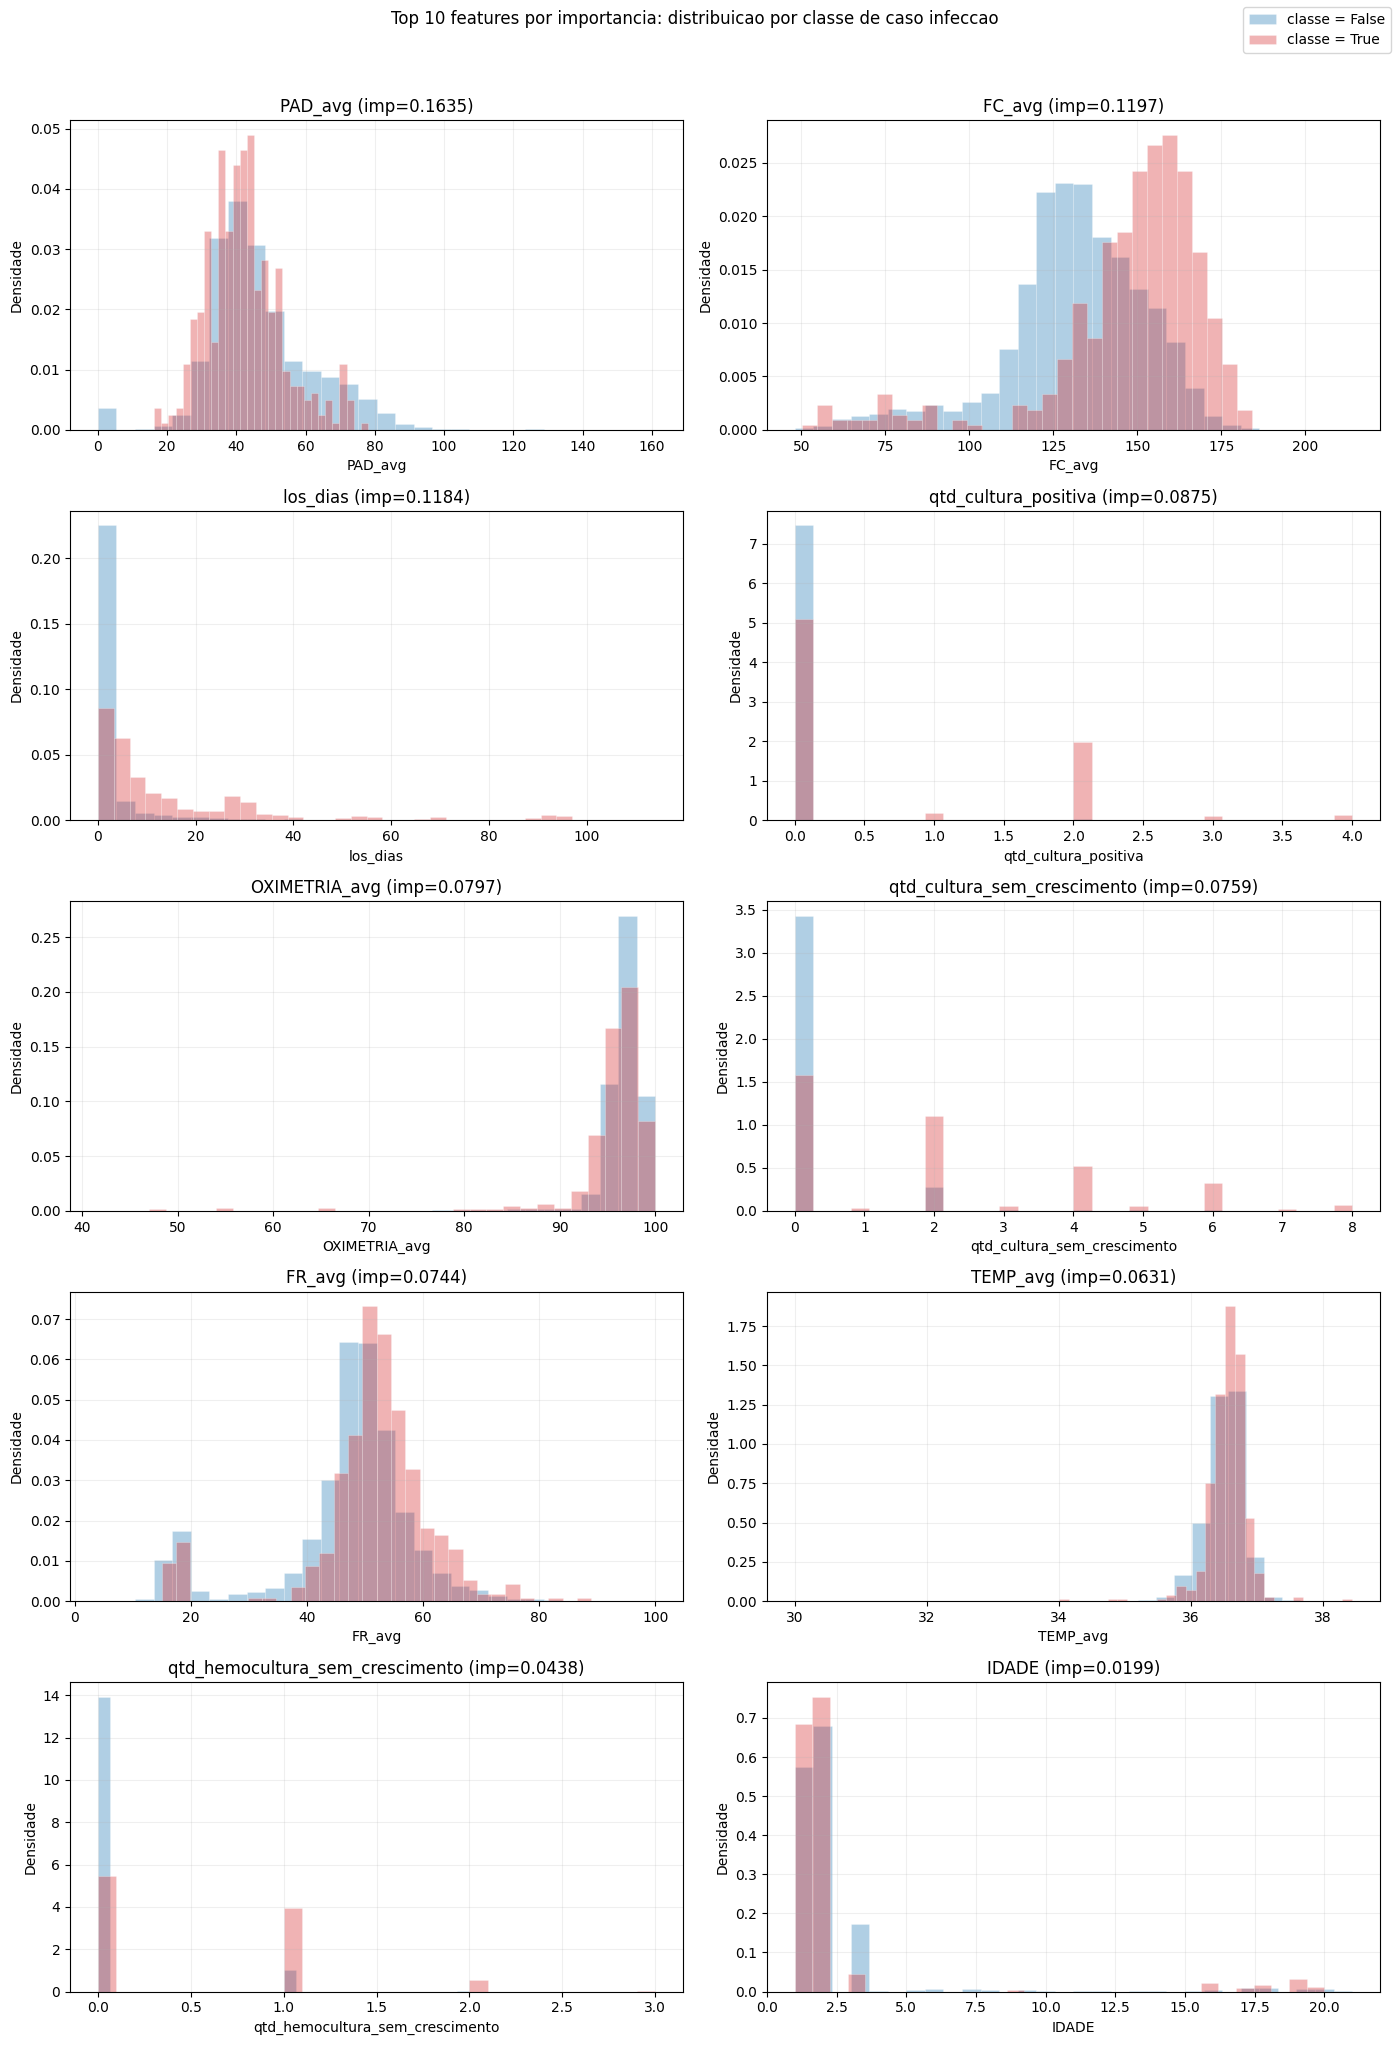

Top 10 features: ['PAD_avg', 'FC_avg', 'los_dias', 'qtd_cultura_positiva', 'OXIMETRIA_avg', 'qtd_cultura_sem_crescimento', 'FR_avg', 'TEMP_avg', 'qtd_hemocultura_sem_crescimento', 'IDADE']


In [27]:
# Distribuicoes das top 10 features por importancia (overlay por classe)
importance_series = pd.Series(model.feature_importances_, index=X_texto_test.columns).sort_values(ascending=False)
top10_features = importance_series.head(10).index.tolist()

target_col = "caso infeccao"
plot_base = df_texto_gabarito[[target_col] + top10_features].copy()
plot_base[target_col] = plot_base[target_col].astype(str)
classes = sorted(plot_base[target_col].dropna().unique())
colors = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e"]

n_cols = 2
n_rows = (len(top10_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for idx, feature in enumerate(top10_features):
    ax = axes[idx]
    feature_df = plot_base[[feature, target_col]].dropna()

    for i, classe in enumerate(classes):
        serie = feature_df.loc[feature_df[target_col] == classe, feature]
        ax.hist(
            serie,
            bins=30,
            alpha=0.35,
            density=True,
            label=f"classe = {classe}",
            color=colors[i % len(colors)],
            edgecolor="white",
            linewidth=0.5,
        )

    ax.set_title(f"{feature} (imp={importance_series.loc[feature]:.4f})")
    ax.set_xlabel(feature)
    ax.set_ylabel("Densidade")
    ax.grid(alpha=0.2)

# Remove eixos vazios (caso existam)
for j in range(len(top10_features), len(axes)):
    fig.delaxes(axes[j])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Top 10 features por importancia: distribuicao por classe de caso infeccao", y=1.02)
plt.tight_layout()
plt.show()

print("Top 10 features:", top10_features)